In [2]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix)

from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/oruntu_tanima_proje'
DATASET_DIR = os.path.join(PROJECT, 'dataset')
PREP_DIR    = os.path.join(PROJECT, 'veri_hazirlik')
METHOD1_DIR = os.path.join(PROJECT, 'yontemler', 'yontem1')
MODELS_DIR  = os.path.join(METHOD1_DIR, 'models')
GRAPHS_DIR  = os.path.join(METHOD1_DIR, 'grafikler')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(GRAPHS_DIR, exist_ok=True)

print('GPU:', tf.config.list_physical_devices('GPU'))
print('TF version:', tf.__version__)

# Load the split produced by 01_data_prep
with open(os.path.join(PREP_DIR, 'split_index.json'), 'r') as f:
    split = json.load(f)

def build_pairs(split_part):
    """Return list of (absolute_path, label) tuples."""
    pairs = []
    for cls_name, label in [('yes', 1), ('no', 0)]:
        for rel in split_part[cls_name]:
            pairs.append((os.path.join(PROJECT, rel), label))
    return pairs

train_pairs = build_pairs(split['train'])
val_pairs   = build_pairs(split['val'])
test_pairs  = build_pairs(split['test'])
print(f'TRAIN: {len(train_pairs)}  VAL: {len(val_pairs)}  TEST: {len(test_pairs)}')

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.20.0
TRAIN: 2100  VAL: 300  TEST: 600


In [3]:
IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Augmentation layer (applied to TRAIN ONLY)
augmenter = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomBrightness(0.1),
], name='augmenter')

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)  # raw pixels in [0, 255]
    return img, label

def build_dataset(pairs, training=False):
    paths  = [p for p, _ in pairs]
    labels = [l for _, l in pairs]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(pairs), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = build_dataset(train_pairs, training=True)
val_ds   = build_dataset(val_pairs,   training=False)
test_ds  = build_dataset(test_pairs,  training=False)

# Sanity peek
for x, y in train_ds.take(1):
    print('Batch shape:', x.shape, 'Pixel range:', float(x.numpy().min()), '-', float(x.numpy().max()))
    print('Labels in batch:', y.numpy()[:8])

Batch shape: (32, 224, 224, 3) Pixel range: 0.0 - 255.0
Labels in batch: [0 1 1 0 1 0 0 1]


In [4]:
def build_classifier(backbone, preprocess_fn=None, dropout=0.3):
    """Wrap a backbone with optional preprocessing + GAP head + sigmoid output."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs if preprocess_fn is None else keras.layers.Lambda(preprocess_fn)(inputs)
    x = backbone(x)
    if len(x.shape) == 4:
        x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

def train_two_phase(model, backbone, train_ds, val_ds,
                    phase_a_epochs=5, phase_b_epochs=20,
                    phase_a_lr=1e-3, phase_b_lr=1e-5,
                    unfreeze_last_n=30):
    """Phase A: head only. Phase B: unfreeze the last N layers of backbone."""
    callbacks = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                      monitor='val_loss'),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5,
                                          monitor='val_loss', min_lr=1e-7),
    ]
    # PHASE A — frozen backbone
    backbone.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(phase_a_lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    print('\n--- PHASE A: backbone frozen, warm-up head ---')
    h1 = model.fit(train_ds, validation_data=val_ds,
                   epochs=phase_a_epochs, callbacks=callbacks, verbose=1)

    # PHASE B — unfreeze the top of the backbone
    backbone.trainable = True
    for layer in backbone.layers[:-unfreeze_last_n]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(phase_b_lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    print(f'\n--- PHASE B: fine-tune last {unfreeze_last_n} backbone layers ---')
    h2 = model.fit(train_ds, validation_data=val_ds,
                   epochs=phase_b_epochs, callbacks=callbacks, verbose=1)

    merged = {k: h1.history[k] + h2.history[k] for k in h1.history.keys()}
    return merged

def plot_history(history, model_name, save_dir):
    epochs = range(1, len(history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history['accuracy'],     label='train')
    axes[0].plot(epochs, history['val_accuracy'], label='val')
    axes[0].set_title(f'{model_name} — Accuracy vs Epoch')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
    axes[1].plot(epochs, history['loss'],     label='train')
    axes[1].plot(epochs, history['val_loss'], label='val')
    axes[1].set_title(f'{model_name} — Loss vs Epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    path = os.path.join(save_dir, f'{model_name}_history.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved plot: {path}')

def evaluate_model(model, test_ds, model_name):
    y_true, y_pred = [], []
    for x, y in test_ds:
        p = model.predict(x, verbose=0).flatten()
        y_pred.extend((p > 0.5).astype(int))
        y_true.extend(y.numpy())
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _   = precision_recall_fscore_support(y_true, y_pred,
                                                          average='binary', pos_label=1)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred,
                                                              average='macro')
    cm = confusion_matrix(y_true, y_pred)
    print(f'\n=== {model_name} — Test results ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}  (macro {prec_m:.4f})')
    print(f'  Recall   : {rec:.4f}  (macro {rec_m:.4f})')
    print(f'  F1       : {f1:.4f}  (macro {f1_m:.4f})')
    print(f'  Confusion matrix (rows=true, cols=pred), order=[no, yes]:\n{cm}')
    return {'model': model_name,
            'accuracy': float(acc),
            'precision': float(prec), 'recall': float(rec), 'f1': float(f1),
            'precision_macro': float(prec_m), 'recall_macro': float(rec_m),
            'f1_macro': float(f1_m),
            'confusion_matrix': cm.tolist()}

def save_artifacts(model, history, metrics, train_time, model_name):
    model.save(os.path.join(MODELS_DIR, f'{model_name}.keras'))
    out = {'model': model_name,
           'train_time_sec': train_time,
           'history': history,
           'metrics': metrics}
    with open(os.path.join(METHOD1_DIR, f'{model_name}_results.json'), 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Artifacts saved for {model_name}')


========== Training: efficientnetb0 ==========
Backbone params: 4,049,571
Total params   : 4,050,852

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 556s 8s/step - accuracy: 0.7052 - loss: 0.5638 - val_accuracy: 0.8233 - val_loss: 0.4411 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 383ms/step - accuracy: 0.8343 - loss: 0.4013 - val_accuracy: 0.8767 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 412ms/step - accuracy: 0.8662 - loss: 0.3347 - val_accuracy: 0.9033 - val_loss: 0.3082 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 415ms/step - accuracy: 0.8710 - loss: 0.3196 - val_accuracy: 0.9100 - val_loss: 0.2813 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 409ms/step - accuracy: 0.8810 - loss: 0.3005 - val_accuracy: 0.9133 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 389ms/step - accuracy: 0.8957 - loss: 0.2795 

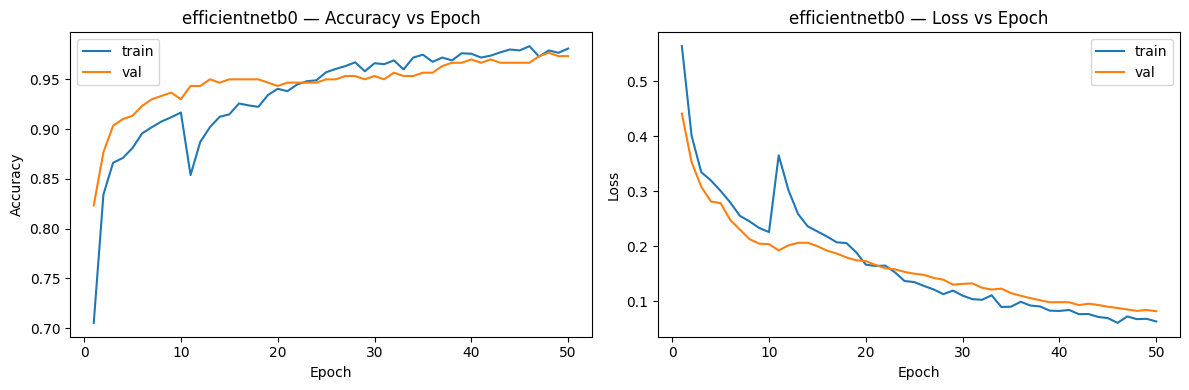

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/efficientnetb0_history.png

=== efficientnetb0 — Test results ===
  Accuracy : 0.9650
  Precision: 0.9515  (macro 0.9654)
  Recall   : 0.9800  (macro 0.9650)
  F1       : 0.9655  (macro 0.9650)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[285  15]
 [  6 294]]
Artifacts saved for efficientnetb0


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pp

MODEL_NAME = 'efficientnetb0'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=effnet_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)


========== Training: xception ==========
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Backbone params: 20,861,480
Total params   : 20,863,529

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 929ms/step - accuracy: 0.7324 - loss: 0.5294 - val_accuracy: 0.8233 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 454ms/step - accuracy: 0.8400 - loss: 0.3831 - val_accuracy: 0.8700 - val_loss: 0.3361 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 422ms/step - accuracy: 0.8629 - loss: 0.3383 - val_accuracy: 0.8667 - val_loss: 0.3219 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.8833 - loss: 0.3069 - val_accuracy: 0.8867 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.8819 - loss: 0.2946 - val_accuracy: 0.8933 - val_loss: 0.2733 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 

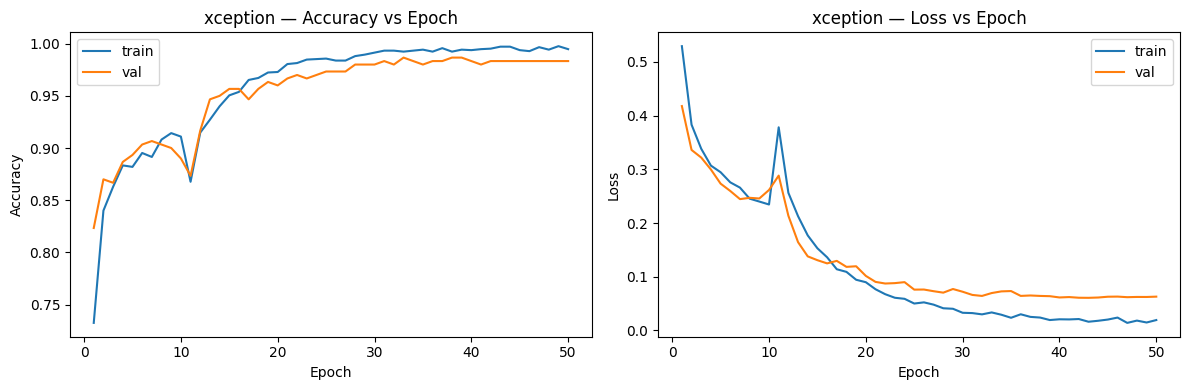

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/xception_history.png

=== xception — Test results ===
  Accuracy : 0.9867
  Precision: 0.9834  (macro 0.9867)
  Recall   : 0.9900  (macro 0.9867)
  F1       : 0.9867  (macro 0.9867)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[295   5]
 [  3 297]]
Artifacts saved for xception


In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_pp

MODEL_NAME = 'xception'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = Xception(include_top=False, weights='imagenet',
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=xception_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)


========== Training: inceptionv3 ==========
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Backbone params: 21,802,784
Total params   : 21,804,833

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 69s 760ms/step - accuracy: 0.7024 - loss: 0.5641 - val_accuracy: 0.8233 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 498ms/step - accuracy: 0.8319 - loss: 0.3911 - val_accuracy: 0.8567 - val_loss: 0.3494 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 434ms/step - accuracy: 0.8495 - loss: 0.3469 - val_accuracy: 0.8667 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms/step - accuracy: 0.8652 - loss: 0.3246 - val_accuracy: 0.8767 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.8871 - loss: 0.2801 - val_accuracy: 0.8767 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━

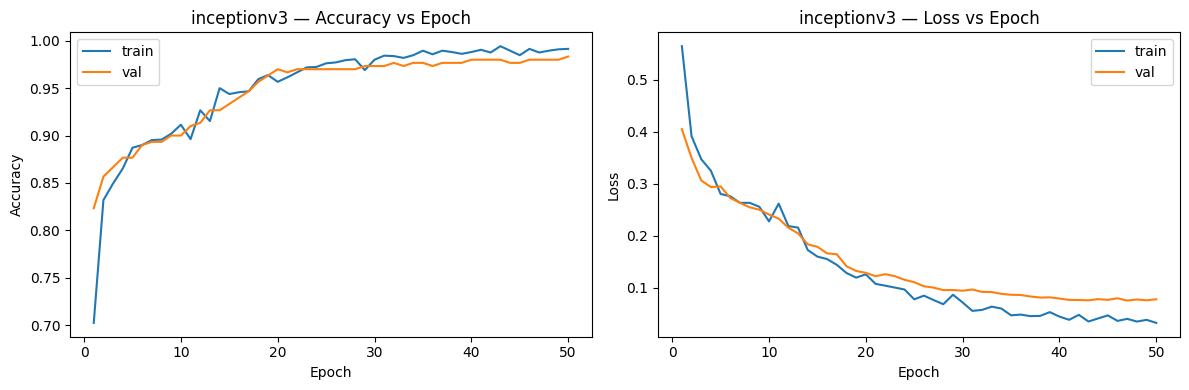

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/inceptionv3_history.png

=== inceptionv3 — Test results ===
  Accuracy : 0.9883
  Precision: 0.9867  (macro 0.9883)
  Recall   : 0.9900  (macro 0.9883)
  F1       : 0.9884  (macro 0.9883)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[296   4]
 [  3 297]]
Artifacts saved for inceptionv3


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pp

MODEL_NAME = 'inceptionv3'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = InceptionV3(include_top=False, weights='imagenet',
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=inception_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)


========== Training: vgg19 ==========
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Backbone params: 20,024,384
Total params   : 20,024,897

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 69s 764ms/step - accuracy: 0.5319 - loss: 1.9504 - val_accuracy: 0.6067 - val_loss: 0.9951 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 451ms/step - accuracy: 0.6729 - loss: 1.0144 - val_accuracy: 0.7267 - val_loss: 0.6423 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 447ms/step - accuracy: 0.7338 - loss: 0.7823 - val_accuracy: 0.8033 - val_loss: 0.5193 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 438ms/step - accuracy: 0.7781 - loss: 0.6159 - val_accuracy: 0.8267 - val_loss: 0.4503 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 438ms/step - accuracy: 0.7905 - loss: 0.5487 - val_accuracy: 0.8267 - val_loss: 0.4201 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s

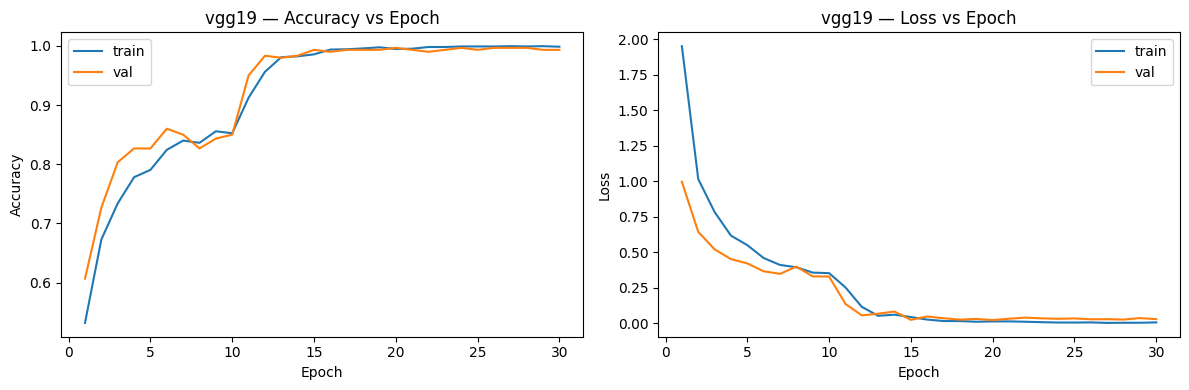

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/vgg19_history.png

=== vgg19 — Test results ===
  Accuracy : 0.9883
  Precision: 0.9835  (macro 0.9884)
  Recall   : 0.9933  (macro 0.9883)
  F1       : 0.9884  (macro 0.9883)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[295   5]
 [  2 298]]
Artifacts saved for vgg19


In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_pp

MODEL_NAME = 'vgg19'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = VGG19(include_top=False, weights='imagenet',
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=vgg19_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)


========== Training: resnet101 ==========
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Backbone params: 42,658,176
Total params   : 42,660,225

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 69s 712ms/step - accuracy: 0.7414 - loss: 0.5250 - val_accuracy: 0.8933 - val_loss: 0.3099 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.8586 - loss: 0.3265 - val_accuracy: 0.9133 - val_loss: 0.2486 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 445ms/step - accuracy: 0.8762 - loss: 0.2914 - val_accuracy: 0.9267 - val_loss: 0.2298 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.9057 - loss: 0.2441 - val_accuracy: 0.9333 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 433ms/step - accuracy: 0.9105 - loss: 0.2314 - val_accuracy: 0.9233 - val_loss: 0.2327 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━

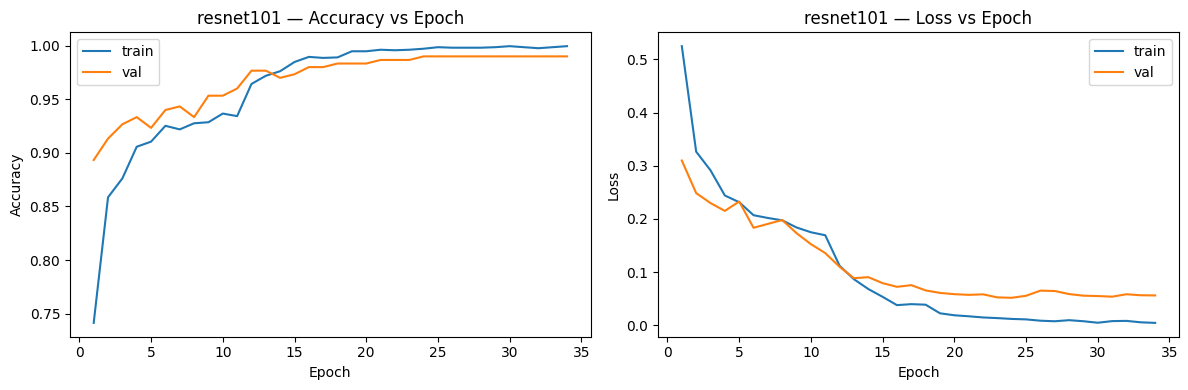

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/resnet101_history.png

=== resnet101 — Test results ===
  Accuracy : 0.9883
  Precision: 0.9933  (macro 0.9884)
  Recall   : 0.9833  (macro 0.9883)
  F1       : 0.9883  (macro 0.9883)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[298   2]
 [  5 295]]
Artifacts saved for resnet101


In [ ]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input as resnet_pp

MODEL_NAME = 'resnet101'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = ResNet101(include_top=False, weights='imagenet',
                     input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=resnet_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)


========== Training: densenet121 ==========
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Backbone params: 7,037,504
Total params   : 7,038,529

--- PHASE A: backbone frozen, warm-up head ---
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6905 - loss: 0.5956 - val_accuracy: 0.7867 - val_loss: 0.4654 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 403ms/step - accuracy: 0.7938 - loss: 0.4505 - val_accuracy: 0.8867 - val_loss: 0.3716 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 398ms/step - accuracy: 0.8348 - loss: 0.3807 - val_accuracy: 0.8933 - val_loss: 0.3300 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 415ms/step - accuracy: 0.8400 - loss: 0.3712 - val_accuracy: 0.9067 - val_loss: 0.3062 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 393ms/step - accuracy: 0.8743 - loss: 0.3261 - val_accuracy: 0.9200 - val_loss: 0.2863 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4

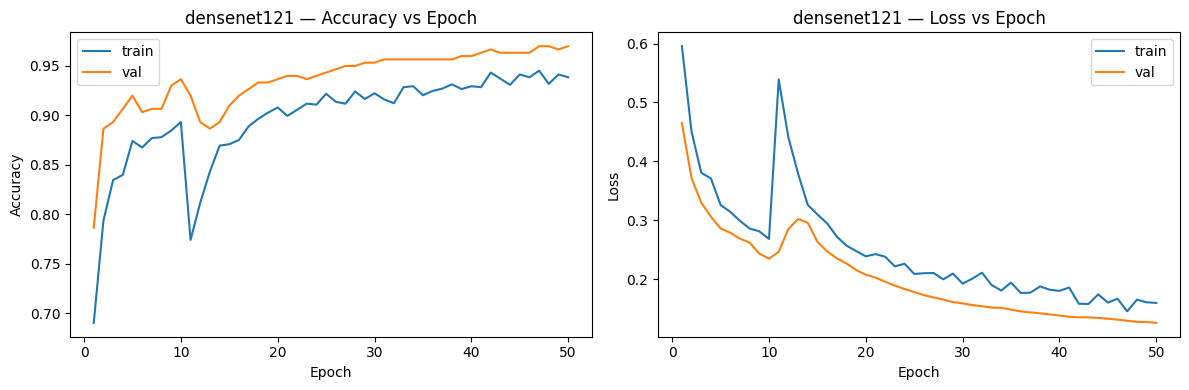

Saved plot: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/densenet121_history.png

=== densenet121 — Test results ===
  Accuracy : 0.9583
  Precision: 0.9450  (macro 0.9587)
  Recall   : 0.9733  (macro 0.9583)
  F1       : 0.9589  (macro 0.9583)
  Confusion matrix (rows=true, cols=pred), order=[no, yes]:
[[283  17]
 [  8 292]]
Artifacts saved for densenet121


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_pp

MODEL_NAME = 'densenet121'
print(f'\n========== Training: {MODEL_NAME} ==========')

backbone = DenseNet121(include_top=False, weights='imagenet',
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = build_classifier(backbone, preprocess_fn=densenet_pp)
print(f'Backbone params: {backbone.count_params():,}')
print(f'Total params   : {model.count_params():,}')

t0 = time.perf_counter()
history = train_two_phase(model, backbone, train_ds, val_ds,
                          phase_a_epochs=10, phase_b_epochs=40,
                          phase_a_lr=1e-3, phase_b_lr=1e-5,
                          unfreeze_last_n=30)
train_time = time.perf_counter() - t0
print(f'\nTotal training time: {train_time:.1f} sec ({train_time/60:.1f} min)')

plot_history(history, MODEL_NAME, GRAPHS_DIR)
metrics = evaluate_model(model, test_ds, MODEL_NAME)
save_artifacts(model, history, metrics, train_time, MODEL_NAME)

In [ ]:
import json, glob, os
import pandas as pd

result_files = sorted(glob.glob(os.path.join(METHOD1_DIR, '*_results.json')))
rows = []
for rf in result_files:
    with open(rf) as f:
        r = json.load(f)
    m = r['metrics']
    cm = m['confusion_matrix']   # [[TN, FP], [FN, TP]]
    rows.append({
        'Model':           r['model'],
        'Accuracy':        m['accuracy'],
        'Precision':       m['precision'],
        'Recall':          m['recall'],
        'F1':              m['f1'],
        'Macro F1':        m['f1_macro'],
        'FN':              cm[1][0],
        'FP':              cm[0][1],
        'Train time (min)': round(r['train_time_sec'] / 60, 1),
    })

df = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)

csv_path = os.path.join(METHOD1_DIR, 'sonuc_tablosu.csv')
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}\n')

# Pretty print
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(df.to_string(index=False))

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/sonuc_tablosu.csv

         Model  Accuracy  Precision  Recall     F1  Macro F1  FN  FP  Train time (min)
         vgg19    0.9883     0.9835  0.9933 0.9884    0.9883   2   5           25.8000
   inceptionv3    0.9883     0.9867  0.9900 0.9884    0.9883   3   4           27.7000
     resnet101    0.9883     0.9933  0.9833 0.9883    0.9883   5   2           19.1000
      xception    0.9867     0.9834  0.9900 0.9867    0.9867   3   5           29.1000
efficientnetb0    0.9650     0.9515  0.9800 0.9655    0.9650   6  15           34.9000
   densenet121    0.9583     0.9450  0.9733 0.9589    0.9583   8  17           28.5000


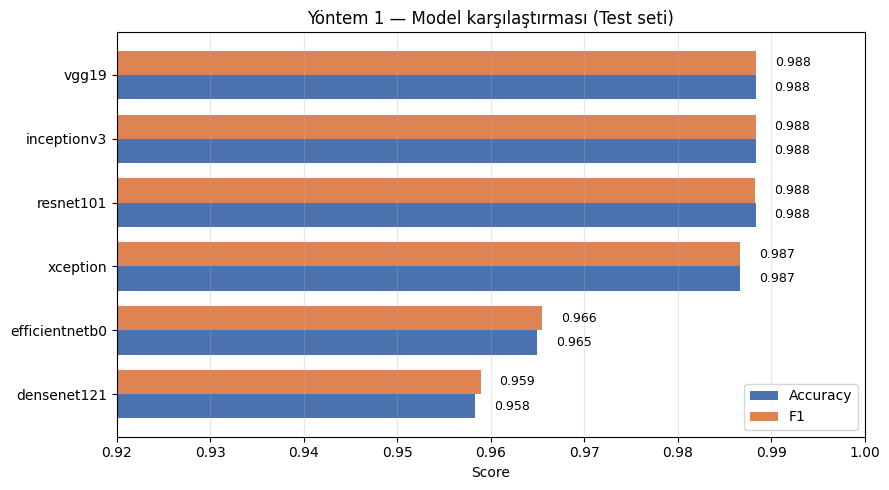

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/method1_comparison_simple.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_sorted = df.sort_values('F1', ascending=True)  # horizontal bar reads bottom-up
models = df_sorted['Model'].tolist()
acc = df_sorted['Accuracy'].values
f1  = df_sorted['F1'].values

y = np.arange(len(models))
h = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y - h/2, acc, h, label='Accuracy', color='#4C72B0')
ax.barh(y + h/2, f1,  h, label='F1',       color='#DD8452')

for i, v in enumerate(acc): ax.text(v + 0.002, i - h/2, f'{v:.3f}', va='center', fontsize=9)
for i, v in enumerate(f1):  ax.text(v + 0.002, i + h/2, f'{v:.3f}', va='center', fontsize=9)

ax.set_yticks(y); ax.set_yticklabels(models)
ax.set_xlim(0.92, 1.0)
ax.set_xlabel('Score')
ax.set_title('Yöntem 1 — Model karşılaştırması (Test seti)')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

out = os.path.join(GRAPHS_DIR, 'method1_comparison_simple.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

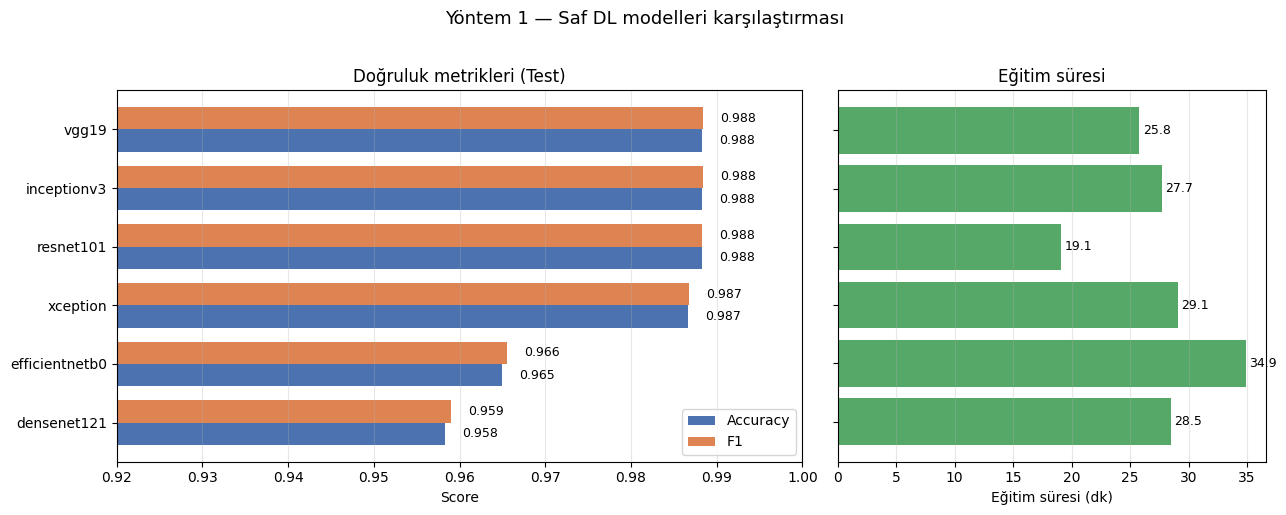

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/method1_comparison_two_panel.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_sorted = df.sort_values('F1', ascending=True)
models = df_sorted['Model'].tolist()
acc = df_sorted['Accuracy'].values
f1  = df_sorted['F1'].values
t   = df_sorted['Train time (min)'].values

y = np.arange(len(models))
h = 0.38

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={'width_ratios': [1.6, 1]})

# Left: Accuracy + F1
ax1.barh(y - h/2, acc, h, label='Accuracy', color='#4C72B0')
ax1.barh(y + h/2, f1,  h, label='F1',       color='#DD8452')
for i, v in enumerate(acc): ax1.text(v + 0.002, i - h/2, f'{v:.3f}', va='center', fontsize=9)
for i, v in enumerate(f1):  ax1.text(v + 0.002, i + h/2, f'{v:.3f}', va='center', fontsize=9)
ax1.set_yticks(y); ax1.set_yticklabels(models)
ax1.set_xlim(0.92, 1.0)
ax1.set_xlabel('Score'); ax1.set_title('Doğruluk metrikleri (Test)')
ax1.legend(loc='lower right'); ax1.grid(axis='x', alpha=0.3)

# Right: training time
ax2.barh(y, t, color='#55A868')
for i, v in enumerate(t): ax2.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)
ax2.set_yticks(y); ax2.set_yticklabels([])
ax2.set_xlabel('Eğitim süresi (dk)'); ax2.set_title('Eğitim süresi')
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Yöntem 1 — Saf DL modelleri karşılaştırması', fontsize=13, y=1.02)
plt.tight_layout()

out = os.path.join(GRAPHS_DIR, 'method1_comparison_two_panel.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

Best model by F1: vgg19 (F1=0.9884)


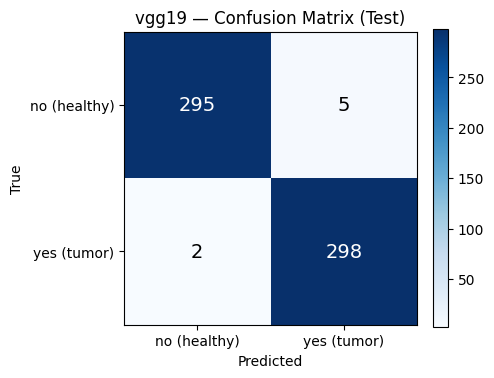

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/grafikler/method1_best_vgg19_cm.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best = df.iloc[0]   # already sorted by F1 desc
best_model = best['Model']
print(f'Best model by F1: {best_model} (F1={best["F1"]:.4f})')

# Reload its results to get the confusion matrix
with open(os.path.join(METHOD1_DIR, f'{best_model}_results.json')) as f:
    cm = np.array(json.load(f)['metrics']['confusion_matrix'])

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1], ['no (healthy)', 'yes (tumor)'])
ax.set_yticks([0, 1], ['no (healthy)', 'yes (tumor)'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'{best_model} — Confusion Matrix (Test)')

# Cell annotations (high-contrast text on dark cells)
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=14)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

out = os.path.join(GRAPHS_DIR, f'method1_best_{best_model}_cm.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [6]:
import os, json, glob, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Import ALL preprocess functions used across the 6 models
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pp
from tensorflow.keras.applications.xception     import preprocess_input as xception_pp
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pp
from tensorflow.keras.applications.vgg19        import preprocess_input as vgg19_pp
from tensorflow.keras.applications.resnet       import preprocess_input as resnet_pp
from tensorflow.keras.applications.densenet     import preprocess_input as densenet_pp

# Map each model name to its preprocess fn (for custom_objects during load)
PP_MAP = {
    'efficientnetb0': effnet_pp,
    'xception':       xception_pp,
    'inceptionv3':    inception_pp,
    'vgg19':          vgg19_pp,
    'resnet101':      resnet_pp,
    'densenet121':    densenet_pp,
}

JSON_DIR = os.path.join(METHOD1_DIR, 'json_sonuclar')
result_files = sorted(glob.glob(os.path.join(JSON_DIR, '*_results.json')))
print(f'Found {len(result_files)} result files')

rows = []
for rf in result_files:
    with open(rf) as f:
        r = json.load(f)
    model_name = r['model']
    print(f'\n>>> Measuring test time for: {model_name}')

    model_path = os.path.join(MODELS_DIR, f'{model_name}.keras')
    pp_fn = PP_MAP.get(model_name)

    # Load with the preprocess fn provided + safe_mode off (needed for Lambda)
    model = keras.models.load_model(
        model_path,
        custom_objects={'preprocess_input': pp_fn},
        safe_mode=False,
        compile=False,
    )

    t0 = time.perf_counter()
    _ = model.predict(test_ds, verbose=0)
    test_time = time.perf_counter() - t0

    train_time = r['train_time_sec']
    total_time = train_time + test_time
    print(f'  Train: {train_time:7.1f}s   Test: {test_time:6.1f}s   TOTAL: {total_time:7.1f}s')

    r['test_time_sec']       = float(test_time)
    r['train_test_time_sec'] = float(total_time)
    with open(rf, 'w') as f:
        json.dump(r, f, indent=2)

    m = r['metrics']; cm = m['confusion_matrix']
    rows.append({
        'Model':            model_name,
        'Accuracy':         m['accuracy'],
        'Precision':        m['precision'],
        'Recall':           m['recall'],
        'F1':               m['f1'],
        'Macro F1':         m['f1_macro'],
        'FN':               cm[1][0],
        'FP':               cm[0][1],
        'Train time (s)':   round(train_time, 1),
        'Test time (s)':    round(test_time, 1),
        'Train+Test (s)':   round(total_time, 1),
        'Train+Test (min)': round(total_time / 60, 2),
    })

    del model
    tf.keras.backend.clear_session()

df = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
csv_path = os.path.join(METHOD1_DIR, 'sonuc_tablosu.csv')
df.to_csv(csv_path, index=False)
print(f'\nUpdated: {csv_path}')
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(df.to_string(index=False))

Found 6 result files

>>> Measuring test time for: densenet121
  Train:  1709.8s   Test:  105.0s   TOTAL:  1814.8s

>>> Measuring test time for: efficientnetb0
  Train:  2091.9s   Test:   29.4s   TOTAL:  2121.3s

>>> Measuring test time for: inceptionv3
  Train:  1664.7s   Test:   21.0s   TOTAL:  1685.8s

>>> Measuring test time for: resnet101
  Train:  1147.7s   Test:   41.0s   TOTAL:  1188.7s

>>> Measuring test time for: vgg19
  Train:  1550.1s   Test:   25.5s   TOTAL:  1575.5s

>>> Measuring test time for: xception
  Train:  1743.4s   Test:   35.6s   TOTAL:  1779.0s

Updated: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem1/sonuc_tablosu.csv
         Model  Accuracy  Precision  Recall     F1  Macro F1  FN  FP  Train time (s)  Test time (s)  Train+Test (s)  Train+Test (min)
         vgg19    0.9883     0.9835  0.9933 0.9884    0.9883   2   5       1550.1000        25.5000       1575.5000           26.2600
   inceptionv3    0.9883     0.9867  0.9900 0.9884    0.9883   3  